# **11주차 과제**

<b>안내사항</b>
- 셀 출력 결과물은 이미지로 첨부하였습니다.
- Colab에서 확인할 시에 마크다운 셀의 출력 이미지가 안보일 수 있습니다.
- 데이터 정렬에서 인덱스 번호는 따로 신경쓰지 않으셔도 괜찮습니다.  
  ※ 이름, 수치 등의 명시된 조건에 대해서만 신경써주시길 바랍니다.

**확인사항**  
- 함수, 클래스 문제에서는 입력인자를 꼼꼼하게 확인해주시길 바랍니다.  
- print, display 함수도 꼼꼼하게 확인하여 출력 결과를 만들어주시길 바랍니다.
- 데이터에 대한 정보 출력, print 사항도 꼼꼼하게 확인해주시길 바랍니다. 오답의 요인이 될 수 있습니다.

In [1]:
# 불필요한 출력을 없애기 위한 코드입니다.
# 문제풀이와는 무관합니다.
import warnings
warnings.filterwarnings('ignore')

# Q1~Q3. **Python에서 Database 다루기**

## Q1. 데이터베이스로부터 데이터 불러오기

- 데이터 정보 및 준수할 사항
  - **데이터**: 직접 구성한 데이터베이스에 `pokemon` 테이블을 생성하고 데이터를 불러옵니다.
  - **출력 결과와 동일하게**, 필요한 컬럼만 선택하여 불러옵니다.
  - 테이블 생성 시에는 제공된 `.csv` 파일 또는 `.sql` 파일 중 **편리한 방법**을 사용하셔도 됩니다.
  - Q1 문제에서는 **데이터베이스 생성, 테이블 생성, 데이터 삽입 과정은 Python 코드로 수행하지 않아도 됩니다.**

- 쿼리로 반드시 진행해야 할 사항
  - 전체 데이터를 불러온 후 Pandas에서 컬럼을 제거하는 방식이 아니라,   
  **SQL 쿼리 내에서 필요한 컬럼만 선택**하여 불러와야 합니다.  
    컬럼 이름, 컬럼 순서, 컬럼 갯수 모두 평가 요소입니다.

- Pandas로 진행할 사항
  - 쿼리 결과를 불러온 뒤, **Pandas의 DataFrame 정보 출력**을 수행합니다.

In [2]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
conn

In [3]:
cursor = conn.cursor()

query = """
    SELECT distinct Name, Type
    FROM pokemon_prep p 
    WHERE type IN ('GRASS', 'POISON', 'FIRE', 'FLYING', 'DRAGON')
"""

cursor.execute(query)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
tmp_df = pd.DataFrame(result, columns=columns)
display(tmp_df)

,Name,Type
0,Bulbasaur,GRASS
1,Ivysaur,GRASS
2,Venusaur,GRASS
3,Mega Venusaur,GRASS
4,Charmander,FIRE
...,...,...
173,Sliggoo,DRAGON
174,Goodra,DRAGON
175,Noibat,FLYING
176,Noivern,FLYING


In [4]:
# 참고 코드 - Python을 통한 확인
origin_df = pd.read_csv('./data/pokemon_prep.csv')
display(origin_df[origin_df['Type'].isin(['GRASS', 'POISON', 'FIRE', 'FLYING', 'DRAGON'])][['Name','Type']])

,Name,Type
0,Bulbasaur,GRASS
1,Ivysaur,GRASS
2,Venusaur,GRASS
3,Mega Venusaur,GRASS
4,Charmander,FIRE
...,...,...
753,Sliggoo,DRAGON
754,Goodra,DRAGON
768,Noibat,FLYING
769,Noivern,FLYING


## Q2. 포켓몬 타입별 포켓몬 숫자 및 비율 확인

**MySQL은 사용하지 말고, Python과 Pandas를 활용하여 해당 집계를 수행합니다**

- 위 데이터에 대한 집계를 수행합니다.
- type별로 포켓몬 숫자를 집계하여 확인합니다.
- 컬럼 이름과, 데이터 정렬 순서도 채점 요소에 포함됩니다.
- 비율의 경우, 자릿수도 확인해주시길 바랍니다.
- 인덱스 정보는 초기화합니다.

In [5]:
tmp_group = tmp_df.groupby(by='Type', as_index=False)[['Name']].count()
tmp_group.sort_values(by='Name', ascending=False, inplace=True)
tmp_group.rename({'Name':'Number_of_Pokemons'}, axis=1, inplace=True)
tmp_group.reset_index(drop=True, inplace=True)
tmp_group

,Type,Number_of_Pokemons
0,GRASS,69
1,FIRE,50
2,POISON,28
3,DRAGON,27
4,FLYING,4


In [6]:
tmp_group['ratio'] = round(tmp_group['Number_of_Pokemons']/tmp_group['Number_of_Pokemons'].sum()*100, 1)
tmp_group

,Type,Number_of_Pokemons,ratio
0,GRASS,69,38.8
1,FIRE,50,28.1
2,POISON,28,15.7
3,DRAGON,27,15.2
4,FLYING,4,2.2


# Q3. 타입별 포켓몬 숫자 시각화

### ▷ 시각화 조건 및 유의사항
- **색상은 자유롭게 설정**해도 되며, 별도의 지정된 색상은 없습니다.
- **차트 제목은 정확하게 출력**해 주세요.

### ▷ 시각화 종류 및 목적
- **Pie Chart**
  - 타입별 포켓몬의 **비율**을 시각화합니다.

- **Barplot Chart**
  - 타입별 포켓몬의 **개수를 시각화**합니다.
  - **배경 옵션 및 차트 제목** 설정을 포함하여 시각화를 마무리합니다.

In [7]:
print(origin_df.shape)
display(origin_df)

(773, 9)


,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Bulbasaur,GRASS,318,45,49,49,65,65,45
1,Ivysaur,GRASS,405,60,62,63,80,80,60
2,Venusaur,GRASS,525,80,82,83,100,100,80
3,Mega Venusaur,GRASS,625,80,100,123,122,120,80
4,Charmander,FIRE,309,39,52,43,60,50,65
...,...,...,...,...,...,...,...,...,...
768,Noibat,FLYING,245,40,30,35,45,40,55
769,Noivern,FLYING,535,85,70,80,97,80,123
770,Xerneas,FAIRY,680,126,131,95,131,98,99
771,Yveltal,DARK,680,126,131,95,131,98,99


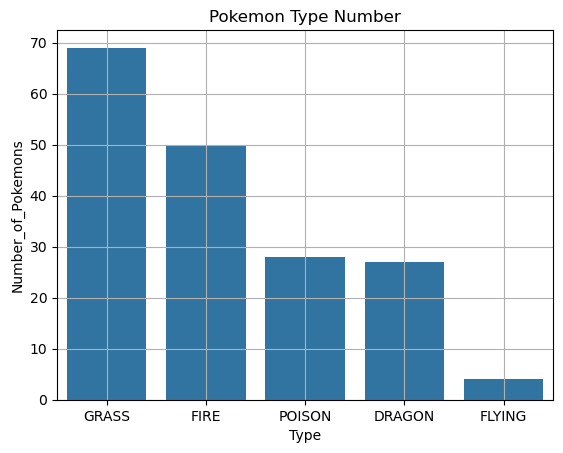

In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

fig = px.pie(
    tmp_group,
    names = 'Type',
    values = 'Number_of_Pokemons',
    title = 'Pokemon Type Ratio'
)
fig.show()

plt.title('Pokemon Type Number')
sns.barplot(data=tmp_group, x='Type', y='Number_of_Pokemons')
plt.grid()
plt.show()

# Q4. 함수 선언
- 데이터 : Q1에서 생성한 데이터에 대해 작업을 수행합니다.
- 함수 동작
    - 특정 컬럼에서 특정 데이터 삭제 후 전후 결과에 대한 비교 시각화를 수행합니다.
    - 데이터 삭제 작업은 쿼리가 아닌 Python에서 수행되어야 합니다.
    - 데이터프레임 출력에서는 컬럼명과 정렬 순서도 꼼꼼하게 확인 부탁드립니다.
    - 별도의 지정된 색상은 없습니다.

============================== 삭제 작업 이전 상태입니다. ==============================
(178, 2)


,Name,Type
0,Bulbasaur,GRASS
1,Ivysaur,GRASS
2,Venusaur,GRASS
3,Mega Venusaur,GRASS
4,Charmander,FIRE


,Type,Number_of_Pokemons
3,GRASS,69
1,FIRE,50
4,POISON,28
0,DRAGON,27
2,FLYING,4


삭제 대상 컬럼 : Type
삭제 대상 데이터 : ['GRASS', 'POISON']
============================== 삭제 작업 이후 상태입니다. ==============================
(81, 2)


,Name,Type
4,Charmander,FIRE
5,Charmeleon,FIRE
6,Charizard,FIRE
7,Mega Charizard X,FIRE
8,Mega Charizard Y,FIRE


,Type,Number_of_Pokemons
1,FIRE,50
0,DRAGON,27
2,FLYING,4


============================== 시각화 결과입니다. ==============================


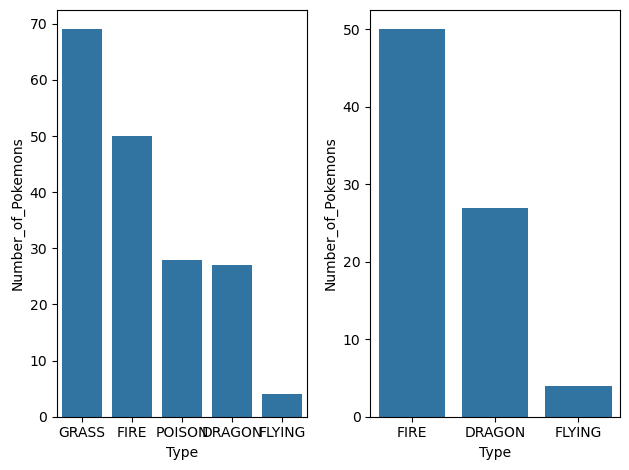

In [9]:
def prep_function(df, drop_col, drop_data):

    print('='* 30, '삭제 작업 이전 상태입니다.', '='*30)
    print(df.shape)    
    display(df.head())    
    df_group = df.groupby(by='Type', as_index=False)[['Name']].count()
    df_group.rename({'Name':'Number_of_Pokemons'}, axis=1, inplace=True)
    df_group.sort_values(by='Number_of_Pokemons', ascending=False, inplace=True)
    display(df_group)
    print(f"삭제 대상 컬럼 : {drop_col}")
    print(f"삭제 대상 데이터 : {drop_data}")
    
    print('='* 30, '삭제 작업 이후 상태입니다.', '='*30)
    drop_data = df[drop_col].isin(drop_data)
    new_df = df[~drop_data]
    print(new_df.shape)    
    display(new_df.head())    
    new_df_group = new_df.groupby(by='Type', as_index=False)[['Name']].count()
    new_df_group.rename({'Name':'Number_of_Pokemons'}, axis=1, inplace=True)
    new_df_group.sort_values(by='Number_of_Pokemons', ascending=False, inplace=True)
    display(new_df_group)

    print('='*30, '시각화 결과입니다.', '='*30)
    plt.subplot(1,2,1)
    sns.barplot(data=df_group, x='Type', y = 'Number_of_Pokemons')

    plt.subplot(1,2,2)
    sns.barplot(data=new_df_group, x='Type', y = 'Number_of_Pokemons')

    plt.tight_layout()
    plt.show()

prep_function(df=tmp_df,
              drop_col = 'Type',
              drop_data = ['GRASS', 'POISON'])


# Q5. 데이터베이스 테이블에서 데이터 삭제

- 작업 개요
    - 데이터 삭제 전, 원본 전체 데이터를 불러와 현재 상태를 확인합니다.
    - 이후 **Python 환경에서 MySQL**를 활용하여 지정된 조건에 따라 **데이터베이스 테이블에서 데이터를 삭제**합니다.

- 유의사항
    - 삭제 작업은 반드시 **SQL 문법**을 사용하여 Python 코드 내에서 실행되어야 합니다.
    - 삭제된 결과가 올바르게 반영되었는지, 삭제 후 테이블 상태를 **재조회하여 확인**해야 합니다.

- 전체 데이터에 대한 정보를 확인합니다.

In [10]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
cursor = conn.cursor()

query = """
    SELECT * 
    FROM pokemon_prep
"""

cursor.execute(query)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
tmp_df = pd.DataFrame(result, columns=columns)
display(tmp_df)

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Bulbasaur,GRASS,318,45,49,49,65,65,45
1,Ivysaur,GRASS,405,60,62,63,80,80,60
2,Venusaur,GRASS,525,80,82,83,100,100,80
3,Mega Venusaur,GRASS,625,80,100,123,122,120,80
4,Charmander,FIRE,309,39,52,43,60,50,65
...,...,...,...,...,...,...,...,...,...
768,Noibat,FLYING,245,40,30,35,45,40,55
769,Noivern,FLYING,535,85,70,80,97,80,123
770,Xerneas,FAIRY,680,126,131,95,131,98,99
771,Yveltal,DARK,680,126,131,95,131,98,99


- 삭제 대상 데이터에 대한 정보를 확인합니다.
    - 삭제 대상 : ('GRASS', 'POISON')

In [11]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
cursor = conn.cursor()

query = """
    SELECT * 
    FROM pokemon_prep
    WHERE TYPE IN ('GRASS', 'POISON')
"""

cursor.execute(query)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
tmp_df = pd.DataFrame(result, columns=columns)
display(tmp_df)

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Bulbasaur,GRASS,318,45,49,49,65,65,45
1,Ivysaur,GRASS,405,60,62,63,80,80,60
2,Venusaur,GRASS,525,80,82,83,100,100,80
3,Mega Venusaur,GRASS,625,80,100,123,122,120,80
4,Ekans,POISON,288,35,60,44,40,54,55
...,...,...,...,...,...,...,...,...,...
92,Chesnaught,GRASS,530,88,107,122,74,75,64
93,Skiddo,GRASS,350,66,65,48,62,57,52
94,Gogoat,GRASS,531,123,100,62,97,81,68
95,Skrelp,POISON,320,50,60,60,60,60,30


- 데이터베이스 테이블에 대해 데이터 삭제 작업을 진행합니다.
    - 데이터베이스 테이블에서 실제로 데이터가 삭제되어야 합니다.
    - 삭제를 진행하고 다시 데이터베이스에서 테이블 정보를 불러와서 삭제가 올바르게 진행되었는지 확인합니다.

In [12]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
cursor = conn.cursor()

query = """
    DELETE FROM pokemon_prep WHERE TYPE IN ('GRASS', 'POISON')
"""

cursor.execute(query)
conn.commit()
cursor.close()
conn.close()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
cursor = conn.cursor()

query = """
    SELECT * 
    FROM pokemon_prep    
"""

cursor.execute(query)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
tmp_df = pd.DataFrame(result, columns=columns)
display(tmp_df)

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Charmander,FIRE,309,39,52,43,60,50,65
1,Charmeleon,FIRE,405,58,64,58,80,65,80
2,Charizard,FIRE,534,78,84,78,109,85,100
3,Mega Charizard X,FIRE,634,78,130,111,130,85,100
4,Mega Charizard Y,FIRE,634,78,104,78,159,115,100
...,...,...,...,...,...,...,...,...,...
671,Noibat,FLYING,245,40,30,35,45,40,55
672,Noivern,FLYING,535,85,70,80,97,80,123
673,Xerneas,FAIRY,680,126,131,95,131,98,99
674,Yveltal,DARK,680,126,131,95,131,98,99


In [12]:
# 전체 데이터에서 삭제 대상 데이터를 제외한 데이터의 갯수를 확인입니다.
773 - 97 == 676

True

# Q6. 테이블에 삭제된 데이터 재삽입

- 작업 개요
    - 이전에 삭제한 데이터를 다시 **데이터베이스 테이블에 삽입**합니다.
    - 삽입이 완료된 후에는 해당 테이블을 다시 불러와 **정상적으로 삽입되었는지 확인**합니다.

- 세부 작업 지침
    - 제공된 **CSV 파일**에서 필요한 데이터만 선택하여 사용합니다.
    - **Python 환경에서 MySQL을 활용하여** 데이터베이스 테이블에 데이터를 삽입합니다.
    - **데이터 정렬 순서는 정답에 영향을 미치지 않습니다.**

In [13]:
import pandas as pd
origin_df = pd.read_csv('./data/pokemon_prep.csv')
display(origin_df.shape)
display(origin_df)
display(origin_df.columns)

(773, 9)

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Bulbasaur,GRASS,318,45,49,49,65,65,45
1,Ivysaur,GRASS,405,60,62,63,80,80,60
2,Venusaur,GRASS,525,80,82,83,100,100,80
3,Mega Venusaur,GRASS,625,80,100,123,122,120,80
4,Charmander,FIRE,309,39,52,43,60,50,65
...,...,...,...,...,...,...,...,...,...
768,Noibat,FLYING,245,40,30,35,45,40,55
769,Noivern,FLYING,535,85,70,80,97,80,123
770,Xerneas,FAIRY,680,126,131,95,131,98,99
771,Yveltal,DARK,680,126,131,95,131,98,99


Index(['Name', 'Type', 'Total', 'HP', 'Attack', 'Defense', 'Special Attack',
       'Special Defense', 'Speed'],
      dtype='object')

- Pandas를 통해 csv에서 'GRASS', 'POISON' 데이터 정보를 확인합니다.

In [14]:
insert_df = origin_df[origin_df['Type'].isin(['GRASS', 'POISON'])]
insert_df

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Bulbasaur,GRASS,318,45,49,49,65,65,45
1,Ivysaur,GRASS,405,60,62,63,80,80,60
2,Venusaur,GRASS,525,80,82,83,100,100,80
3,Mega Venusaur,GRASS,625,80,100,123,122,120,80
26,Ekans,POISON,288,35,60,44,40,54,55
...,...,...,...,...,...,...,...,...,...
699,Chesnaught,GRASS,530,88,107,122,74,75,64
719,Skiddo,GRASS,350,66,65,48,62,57,52
720,Gogoat,GRASS,531,123,100,62,97,81,68
738,Skrelp,POISON,320,50,60,60,60,60,30


In [15]:
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
cursor = conn.cursor()

cursor = conn.cursor()

insert_query_withvalues = """
        INSERT INTO pokemon_prep
        (`Name`, `Type`, `Total`, `HP`, `Attack`, `Defense`, `Special Attack`, `Special Defense`, `Speed`)
        VALUES
        (%(Name)s, %(Type)s, %(Total)s, %(HP)s, %(Attack)s, %(Defense)s, %(Special Attack)s, %(Special Defense)s, %(Speed)s)
        """
    
for idx, val in insert_df.iterrows():
    data_withvalues = {
        'Name' : val['Name'],
        'Type' : val['Type'],
        'Total' : val['Total'],
        'HP' : val['HP'],
        'Attack' : val['Attack'],
        'Defense' : val['Defense'],
        'Special Attack' : val['Special Attack'],
        'Special Defense' : val['Special Defense'],
        'Speed' : val['Speed']
    }
    print(data_withvalues)

    cursor.execute(insert_query_withvalues, data_withvalues)
    
conn.commit()
cursor.close()
print("데이터 INSERT 완료")

{'Name': 'Bulbasaur', 'Type': 'GRASS', 'Total': 318, 'HP': 45, 'Attack': 49, 'Defense': 49, 'Special Attack': 65, 'Special Defense': 65, 'Speed': 45}
{'Name': 'Ivysaur', 'Type': 'GRASS', 'Total': 405, 'HP': 60, 'Attack': 62, 'Defense': 63, 'Special Attack': 80, 'Special Defense': 80, 'Speed': 60}
{'Name': 'Venusaur', 'Type': 'GRASS', 'Total': 525, 'HP': 80, 'Attack': 82, 'Defense': 83, 'Special Attack': 100, 'Special Defense': 100, 'Speed': 80}
{'Name': 'Mega Venusaur', 'Type': 'GRASS', 'Total': 625, 'HP': 80, 'Attack': 100, 'Defense': 123, 'Special Attack': 122, 'Special Defense': 120, 'Speed': 80}
{'Name': 'Ekans', 'Type': 'POISON', 'Total': 288, 'HP': 35, 'Attack': 60, 'Defense': 44, 'Special Attack': 40, 'Special Defense': 54, 'Speed': 55}
{'Name': 'Arbok', 'Type': 'POISON', 'Total': 438, 'HP': 60, 'Attack': 85, 'Defense': 69, 'Special Attack': 65, 'Special Defense': 79, 'Speed': 80}
{'Name': 'Nidoran♀', 'Type': 'POISON', 'Total': 275, 'HP': 55, 'Attack': 47, 'Defense': 52, 'Specia

In [16]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='metacode_11th'
)
conn

cursor = conn.cursor()

query = """
    SELECT *
    FROM pokemon_prep p 
"""

cursor.execute(query)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
tmp_df = pd.DataFrame(result, columns=columns)
display(tmp_df)

,Name,Type,Total,HP,Attack,Defense,Special Attack,Special Defense,Speed
0,Charmander,FIRE,309,39,52,43,60,50,65
1,Charmeleon,FIRE,405,58,64,58,80,65,80
2,Charizard,FIRE,534,78,84,78,109,85,100
3,Mega Charizard X,FIRE,634,78,130,111,130,85,100
4,Mega Charizard Y,FIRE,634,78,104,78,159,115,100
...,...,...,...,...,...,...,...,...,...
768,Chesnaught,GRASS,530,88,107,122,74,75,64
769,Skiddo,GRASS,350,66,65,48,62,57,52
770,Gogoat,GRASS,531,123,100,62,97,81,68
771,Skrelp,POISON,320,50,60,60,60,60,30


## **🔎 [주관식 과제 수행 시 유의사항]**

> **✅ 1. 정확한 출력값과 요구사항 이행 필수**  

주관식 채점은 다음 기준에 따라 평가됩니다.

1)출력 결과의 정확성  
- 제공된 예시 결과와 동일한 출력이 나와야 합니다.  
- 단, 실시간 데이터나 인공지능 학습 등으로 출력값에 변동성이 존재할 수 있는 문제는 예외로 처리합니다.  

2)문제 요구사항의 충실한 반영  
- 조건, 컬럼명, 출력 형식 등 모든 요구사항을 빠짐없이 반영해야 합니다.  
- 사소한 조건도 놓치지 않도록 세심하게 코드를 작성해 주세요.  


> **✅ 2. 완성된 코드 제출 필수**

가. 제출한 코드 셀은 채점 시 직접 실행하여 결과를 확인할 수 있습니다.  

- 재실행 시에도 동일한 결과가 나와야 정답으로 인정됩니다.  

나. 버전 차이에 따른 미세한 수치 차이는 감안하나, 결과 형태나 구조가 다르면 감점 또는 오답 처리될 수 있습니다.  

다. 시각화 문제에서 색상 지정이 없다면, 기본(default) 색상 사용을 전제로 합니다.  
- 환경에 따라 색상이 다르게 출력되더라도 불이익은 없습니다.  

> **✅ 3. 사용자 선언 함수/클래스 문제 주의사항**

사용자 정의 함수, 클래스, 메서드와 관련된 문제에서는 추가적인 코드 없이도 함수만으로 정답 결과가 도출되어야 합니다.  
- ❌ 함수 외부에서 plt.title, print, info() 등을 추가하여 결과를 보완하면 오답 처리됩니다.  

> **✅ 4. 함수/클래스 선언 시 일관된 결과 유지**

가. 함수, 클래스, 메서드는 반복 실행 시에도 항상 동일한 결과를 반환해야 합니다.  
나. 채점 중 재실행 결과가 다르면 오답으로 처리됩니다.  

> **📌 [안내 정리]**  

가. 문제의 모든 조건을 꼼꼼히 확인하고 반영해 주세요.  
나. 과제는 실무와 유사한 기준으로 평가되며, 요구 조건을 충족하지 않을 경우 0점 처리될 수 있습니다.  